In [39]:
from matplotlib import pyplot as plt
import numpy as np
import h5py

def load_particles_from_h5(filename):
    result = {}

    with h5py.File(filename, "r") as f:
        # For each category (ggF_train, ggF_test, VBF_train, etc.)
        for category_name in f.keys():
            category_data = {}
            
            # For each particle/object group within the category
            for group_name in f[category_name].keys():
                group_data = {}

                # Load datasets (numpy arrays)
                if isinstance(f[category_name][group_name], h5py.Group):
                    for dataset_name in f[category_name][group_name].keys():
                        group_data[dataset_name] = f[category_name][group_name][dataset_name][:]

                    # Load attributes (scalars)
                    for attr_name, attr_value in f[category_name][group_name].attrs.items():
                        group_data[attr_name] = attr_value
                else:
                    # Handle case where it's a dataset directly
                    group_data = f[category_name][group_name][:]

                category_data[group_name] = group_data

            result[category_name] = category_data

    return result

In [40]:
data_path = "/root/data/danning_h5/ypeng/mc20_qe_v4_recotruth_merged.h5"
data = load_particles_from_h5(data_path)

def col(a):
    return a.reshape(a.shape[0], -1)

def deta(eta1, eta2):
    return np.abs(eta1 - eta2)

def dphi_pi(phi1, phi2):
    phi_diff = phi1 - phi2
    phi_diff = np.where(phi_diff < 0.0, -phi_diff, phi_diff)
    phi_diff = np.where(phi_diff > 2.0 * np.pi, phi_diff - 2.0 * np.pi, phi_diff)
    phi_diff = np.where(phi_diff >= np.pi, 2.0 * np.pi - phi_diff, phi_diff)
    return np.divide(phi_diff, np.pi)

# Collect all training and target objects from all categories
all_train_objs = []
all_target_objs = []

# Iterate through all categories (ggF_train, ggF_test, VBF_train, etc.)
for category in data.keys():
    category_data = data[category]
    
    # training features
    lep_pos_px = category_data["pos_lep"]["px"]
    lep_pos_py = category_data["pos_lep"]["py"]
    lep_pos_pz = category_data["pos_lep"]["pz"]
    lep_pos_energy = category_data["pos_lep"]["energy"]
    lep_neg_px = category_data["neg_lep"]["px"]
    lep_neg_py = category_data["neg_lep"]["py"]
    lep_neg_pz = category_data["neg_lep"]["pz"]
    lep_neg_energy = category_data["neg_lep"]["energy"]
    
    lep_pos_eta = category_data["pos_lep"]["eta"]
    lep_neg_eta = category_data["neg_lep"]["eta"]
    lep_pos_phi = category_data["pos_lep"]["phi"]
    lep_neg_phi = category_data["neg_lep"]["phi"]

    met_px = category_data["met"]["px"]
    met_py = category_data["met"]["py"]
    met_phi = category_data["met"]["phi"]
    
    dphi_l1met = dphi_pi(lep_pos_phi, met_phi)
    dphi_l2met = dphi_pi(lep_neg_phi, met_phi)
    dphi_l1l2 = dphi_pi(lep_pos_phi, lep_neg_phi)
    deta_l1l2 = deta(lep_pos_eta, lep_neg_eta)  
    
    jet_px = category_data["jets"]["px"]
    jet_py = category_data["jets"]["py"]
    jet_pz = category_data["jets"]["pz"]
    jet_pt = category_data["jets"]["pt"]
    jet_energy = category_data["jets"]["energy"]
    jet_btag = category_data["jets"]["btag"]
    n_jets = category_data["jets"]["n_jets"]
    n_bjets = category_data["jets"]["n_bjets"]
    
    w_pos_px = category_data["truth_pos_w"]["px"]
    w_pos_py = category_data["truth_pos_w"]["py"]
    w_pos_pz = category_data["truth_pos_w"]["pz"]
    w_pos_energy = category_data["truth_pos_w"]["energy"]
    w_neg_px = category_data["truth_neg_w"]["px"]
    w_neg_py = category_data["truth_neg_w"]["py"]
    w_neg_pz = category_data["truth_neg_w"]["pz"]
    w_neg_energy = category_data["truth_neg_w"]["energy"]
    
    nu_px = category_data["truth_nu"]["px"]
    nu_py = category_data["truth_nu"]["py"]
    nu_pz = category_data["truth_nu"]["pz"]
    nu_energy = category_data["truth_nu"]["energy"]
    antinu_px = category_data["truth_antinu"]["px"]
    antinu_py = category_data["truth_antinu"]["py"]
    antinu_pz = category_data["truth_antinu"]["pz"]
    antinu_energy = category_data["truth_antinu"]["energy"]

In [41]:
from ohbboosting import Booster

w0_p4 = np.stack([w_pos_px, w_pos_py, w_pos_pz, w_pos_energy], axis=1)
l0_p4 = np.stack([lep_pos_px, lep_pos_py, lep_pos_pz, lep_pos_energy], axis=1)
w1_p4 = np.stack([w_neg_px, w_neg_py, w_neg_pz, w_neg_energy], axis=1)
l1_p4 = np.stack([lep_neg_px, lep_neg_py, lep_neg_pz, lep_neg_energy], axis=1)

particles = np.concatenate(
	[
		w0_p4,
		l0_p4,
		w1_p4,
		l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
l0_theta_phi, l1_theta_phi = booster.lep_theta_phi_in_w_rest()

reco_len = particles.shape[0]

(75569, 16)


In [42]:
def v4SM_load_particles_from_h5(filename):
    result = {}

    with h5py.File(filename, "r") as f:
        # For each group in the file
        print(f.keys())
        for group_name in f.keys():
            group_data = {}

            # Load datasets (numpy arrays)
            for dataset_name in f[group_name].keys():
                group_data[dataset_name] = f[group_name][dataset_name][:]

            # Load attributes (scalars)
            for attr_name, attr_value in f[group_name].attrs.items():
                group_data[attr_name] = attr_value

            result[group_name] = group_data

    return result


data = v4SM_load_particles_from_h5("/root/data/mc20_truth_v4_SM.h5")

truth_pos_lep = data["truth_pos_lep"]
truth_neg_lep = data["truth_neg_lep"]
truth_pos_nu = data["truth_pos_nu"]
truth_neg_nu = data["truth_neg_nu"]

truth_lep_pos_px = truth_pos_lep["px"][:reco_len]
truth_lep_pos_py = truth_pos_lep["py"][:reco_len]
truth_lep_pos_pz = truth_pos_lep["pz"][:reco_len]
truth_lep_pos_energy = truth_pos_lep["energy"][:reco_len]
truth_lep_pos_id = truth_pos_lep["pdgId"][:reco_len]
truth_lep_pos_pt = truth_pos_lep["pt"][:reco_len]
truth_lep_pos_eta = truth_pos_lep["eta"][:reco_len]
truth_lep_pos_phi = truth_pos_lep["phi"][:reco_len]

truth_lep_neg_px = truth_neg_lep["px"][:reco_len]
truth_lep_neg_py = truth_neg_lep["py"][:reco_len]
truth_lep_neg_pz = truth_neg_lep["pz"][:reco_len]
truth_lep_neg_energy = truth_neg_lep["energy"][:reco_len]
truth_lep_neg_id = truth_neg_lep["pdgId"][:reco_len]
truth_lep_neg_pt = truth_neg_lep["pt"][:reco_len]
truth_lep_neg_eta = truth_neg_lep["eta"][:reco_len]
truth_lep_neg_phi = truth_neg_lep["phi"][:reco_len]

truth_neg_nu_px = truth_pos_nu["px"][:reco_len]
truth_neg_nu_py = truth_pos_nu["py"][:reco_len]
truth_neg_nu_pz = truth_pos_nu["pz"][:reco_len]
truth_neg_nu_energy = truth_pos_nu["energy"][:reco_len]
truth_pos_nu_px = truth_neg_nu["px"][:reco_len]
truth_pos_nu_py = truth_neg_nu["py"][:reco_len]
truth_pos_nu_pz = truth_neg_nu["pz"][:reco_len]
truth_pos_nu_energy = truth_neg_nu["energy"][:reco_len]
truth_met_px = truth_pos_nu_px + truth_neg_nu_px
truth_met_py = truth_pos_nu_py + truth_neg_nu_py
truth_met = np.sqrt(truth_met_px**2 + truth_met_py**2)
truth_w_pos = data["pos_w"]
truth_w_neg = data["neg_w"]
truth_w_pos_px = truth_w_pos["px"][:reco_len]
truth_w_pos_py = truth_w_pos["py"][:reco_len]
truth_w_pos_pz = truth_w_pos["pz"][:reco_len]
truth_w_pos_e = truth_w_pos["energy"][:reco_len]
truth_w_neg_px = truth_w_neg["px"][:reco_len]
truth_w_neg_py = truth_w_neg["py"][:reco_len]
truth_w_neg_pz = truth_w_neg["pz"][:reco_len]
truth_w_neg_e = truth_w_neg["energy"][:reco_len]
truth_w_pos_m = truth_w_pos["m"][:reco_len]
truth_w_neg_m = truth_w_neg["m"][:reco_len]

<KeysViewHDF5 ['higgs', 'lead_w', 'neg_w', 'pos_w', 'sublead_w', 'truth_dilep', 'truth_dilep_car', 'truth_lead_lep', 'truth_lead_lep_car', 'truth_lead_nu', 'truth_lead_nu_car', 'truth_neg_lep', 'truth_neg_lep_car', 'truth_neg_nu', 'truth_neg_nu_car', 'truth_pos_lep', 'truth_pos_lep_car', 'truth_pos_nu', 'truth_pos_nu_car', 'truth_sublead_lep', 'truth_sublead_lep_car', 'truth_sublead_nu', 'truth_sublead_nu_car']>


In [43]:
print(np.unique(truth_lep_pos_id)) # find the unique pdgid in the array
pos_el = (truth_lep_pos_id == -11)
pos_mu = (truth_lep_pos_id == -13)
print(np.unique(truth_lep_neg_id))
neg_el = (truth_lep_neg_id == 11)
neg_mu = (truth_lep_neg_id == 13)

[-13 -11]
[11 13]


In [44]:
# el selection: abs(eta) < 2.47 and veto crack [1.37, 1.52]
pos_is_e = truth_lep_pos_id == -11
neg_is_e = truth_lep_neg_id == 11
pos_e_accept = (np.abs(truth_lep_pos_eta) < 2.47) & ~((np.abs(truth_lep_pos_eta) > 1.37) & (np.abs(truth_lep_pos_eta) < 1.52))
neg_e_accept = (np.abs(truth_lep_neg_eta) < 2.47) & ~((np.abs(truth_lep_neg_eta) > 1.37) & (np.abs(truth_lep_neg_eta) < 1.52))
el_eta_mask = (pos_is_e & pos_e_accept) | (neg_is_e & neg_e_accept)

# muon selection: abs(eta) < 2.5
pos_is_mu = truth_lep_pos_id == -13
neg_is_mu = truth_lep_neg_id == 13
pos_mu_accept = (np.abs(truth_lep_pos_eta) < 2.5)
neg_mu_accept = (np.abs(truth_lep_neg_eta) < 2.5)
mu_eta_mask = (pos_is_mu & pos_mu_accept) | (neg_is_mu & neg_mu_accept)

eta_mask = el_eta_mask & mu_eta_mask

In [45]:
# lead lep pt > 22 GeV
pos_is_lead = truth_lep_pos_pt > truth_lep_neg_pt
neg_is_lead = truth_lep_neg_pt > truth_lep_pos_pt
pos_lead_lep_accept = pos_is_lead & (truth_lep_pos_pt > 22)
neg_lead_lep_accept = neg_is_lead & (truth_lep_neg_pt > 22)
lead_lep_mask = pos_lead_lep_accept | neg_lead_lep_accept
print("It's binary, so check unique values:", np.unique(pos_lead_lep_accept*1 + neg_lead_lep_accept*1))
assert np.max(np.unique(pos_lead_lep_accept*1 + neg_lead_lep_accept*1)) <= 1, "Leading lep -> Logic error!"
# # do the sanity check (optional)
# lead_lep_pt = np.select([pos_is_lead, neg_is_lead], [truth_lep_pos_pt, truth_lep_neg_pt])
# plt.hist(lead_lep_pt[lead_lep_mask], bins=200, range=(0, 200))
# plt.ylim(0, plt.ylim()[1])
# plt.vlines(22, 0, plt.ylim()[1], colors="red", linestyles="dashed")
# plt.title(r"$p_T^{\ell_0}$")
# plt.show()

# sublead lep pt > 15 GeV
pos_sublead_lep_accept = ~pos_is_lead & (truth_lep_pos_pt > 15)
neg_sublead_lep_accept = ~neg_is_lead & (truth_lep_neg_pt > 15)
sublead_lep_mask = pos_sublead_lep_accept | neg_sublead_lep_accept
print("It's binary, so check unique values:", np.unique(pos_sublead_lep_accept*1 + neg_sublead_lep_accept*1))
assert np.max(np.unique(pos_sublead_lep_accept*1 + neg_sublead_lep_accept*1)) <= 1, "Subleading lep -> Logic error!"
# # do the sanity check (optional)
# sublead_lep_pt = np.select([~pos_is_lead, ~neg_is_lead], [truth_lep_pos_pt, truth_lep_neg_pt])
# plt.hist(sublead_lep_pt[sublead_lep_mask], bins=200, range=(0, 200))
# plt.ylim(0, plt.ylim()[1])
# plt.vlines(15, 0, plt.ylim()[1], colors="red", linestyles="dashed")
# plt.title(r"$p_T^{\ell_1}$")
# plt.show()
pt_mask = lead_lep_mask & sublead_lep_mask

It's binary, so check unique values: [0 1]
It's binary, so check unique values: [0 1]


In [46]:
# dilep mass > 10 GeV
dilep_px = truth_lep_pos_px + truth_lep_neg_px
dilep_py = truth_lep_pos_py + truth_lep_neg_py
dilep_pz = truth_lep_pos_pz + truth_lep_neg_pz
dilep_E = truth_lep_pos_energy + truth_lep_neg_energy
dilep_m_2 = dilep_E**2 - (dilep_px**2 + dilep_py**2 + dilep_pz**2)
dilep_mass_mask = dilep_m_2 > 10**2
# do the sanity check (optional)
# plt.hist(np.sqrt(dilep_m_2[dilep_mass_mask]), bins=200, range=(0, 200))
# plt.ylim(0, plt.ylim()[1])
# plt.vlines(10, 0, plt.ylim()[1], colors="red", linestyles="dashed")
# plt.title(r"$m_{\ell\ell}$")
# plt.show()

In [47]:
# met  > 20 GeV
met_mask = truth_met > 20
# do the sanity check (optional)
# plt.hist(truth_met[met_mask], bins=200, range=(0, 500))
# plt.ylim(0, plt.ylim()[1])
# plt.vlines(20, 0, plt.ylim()[1], colors="red", linestyles="dashed")
# plt.title(r"$E_T^{miss}$")
# plt.show()

In [48]:
def pt(part_p4):
    return np.sqrt(part_p4[:, 0]**2 + part_p4[:, 1]**2)

def mass(part1_p4, part3_p4):
    return np.sqrt((part1_p4[:, 3] + part3_p4[:, 3])**2 - (part1_p4[:, 0] + part3_p4[:, 0])**2 - (part1_p4[:, 1] + part3_p4[:, 1])**2 - (part1_p4[:, 2] + part3_p4[:, 2])**2)

def dR(p1_eta, p1_phi, p2_eta, p2_phi):
    deta = np.abs(p1_eta - p2_eta)
    dphi = np.abs(p1_phi - p2_phi)
    dphi = np.where(dphi > np.pi, 2*np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

def dPhi(p1_phi, p2_phi):
    dphi = np.abs(p1_phi - p2_phi)
    dphi = np.where(dphi > np.pi, 2*np.pi - dphi, dphi)
    return dphi

def dEta(part1_phi, part2_phi):
    return np.abs(part1_phi - part2_phi)

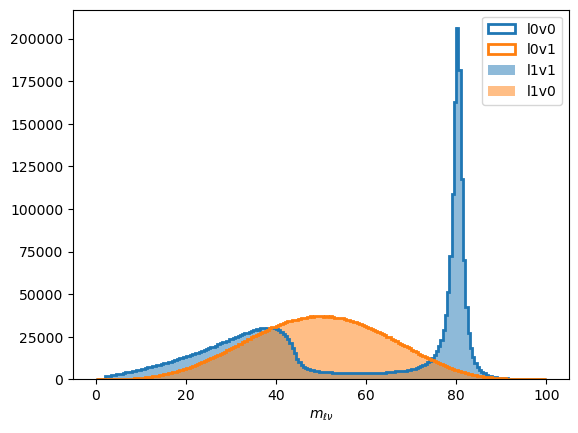

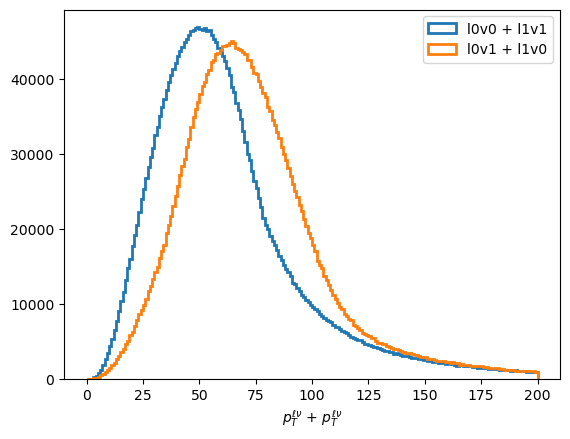

In [49]:
l0v0_p4 = truth_pos_lep["p4"] + truth_neg_nu["p4"]
l0v1_p4 = truth_pos_lep["p4"] + truth_pos_nu["p4"]
l1v1_p4 = truth_neg_lep["p4"] + truth_pos_nu["p4"]
l1v0_p4 = truth_neg_lep["p4"] + truth_neg_nu["p4"]

l0v0_pt = pt(l0v0_p4)
l0v1_pt = pt(l0v1_p4)
l1v1_pt = pt(l1v1_p4)
l1v0_pt = pt(l1v0_p4)

l0v0_mass = mass(truth_pos_lep["p4"], truth_neg_nu["p4"])
l0v1_mass = mass(truth_pos_lep["p4"], truth_pos_nu["p4"])
l1v1_mass = mass(truth_neg_lep["p4"], truth_pos_nu["p4"])
l1v0_mass = mass(truth_neg_lep["p4"], truth_neg_nu["p4"])

l0v0_dR = dR(truth_pos_lep["eta"], truth_pos_lep["phi"], truth_neg_nu["eta"], truth_neg_nu["phi"])
l0v1_dR = dR(truth_pos_lep["eta"], truth_pos_lep["phi"], truth_pos_nu["eta"], truth_pos_nu["phi"])
l1v1_dR = dR(truth_neg_lep["eta"], truth_neg_lep["phi"], truth_pos_nu["eta"], truth_pos_nu["phi"])
l1v0_dR = dR(truth_neg_lep["eta"], truth_neg_lep["phi"], truth_neg_nu["eta"], truth_neg_nu["phi"])

l0v0_dPhi = dPhi(truth_pos_lep["phi"], truth_neg_nu["phi"])
l0v1_dPhi = dPhi(truth_pos_lep["phi"], truth_pos_nu["phi"])
l1v1_dPhi = dPhi(truth_neg_lep["phi"], truth_pos_nu["phi"])
l1v0_dPhi = dPhi(truth_neg_lep["phi"], truth_neg_nu["phi"])

l0v0_dEta = dEta(truth_pos_lep["eta"], truth_neg_nu["eta"])
l0v1_dEta = dEta(truth_pos_lep["eta"], truth_pos_nu["eta"])
l1v1_dEta = dEta(truth_neg_lep["eta"], truth_pos_nu["eta"])
l1v0_dEta = dEta(truth_neg_lep["eta"], truth_neg_nu["eta"])


plt.hist(l0v0_mass, bins=200, range=(0, 100), linewidth=2, label="l0v0", histtype="step", color="tab:blue")
plt.hist(l0v1_mass, bins=200, range=(0, 100), linewidth=2, label="l0v1", histtype="step", color="tab:orange")
plt.hist(l1v1_mass, bins=200, range=(0, 100), alpha=0.5, label="l1v1", color="tab:blue")
plt.hist(l1v0_mass, bins=200, range=(0, 100), alpha=0.5, label="l1v0", color="tab:orange")
plt.xlabel(r"$m_{\ell\nu}$")
plt.legend()
plt.show()

plt.hist(l0v0_pt + l1v1_pt, bins=200, range=(0, 200), linewidth=2, label="l0v0 + l1v1", histtype="step", color="tab:blue")
plt.hist(l0v1_pt + l1v0_pt, bins=200, range=(0, 200), linewidth=2, label="l0v1 + l1v0", histtype="step", color="tab:orange")
plt.xlabel(r"$p_T^{\ell\nu}$ + $p_T^{\ell\nu}$")
plt.legend()
plt.show()

Mass criteria 0.9182449869883057


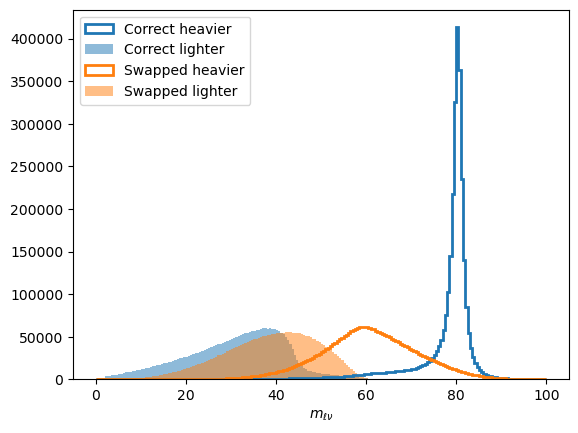

Pt criteria 0.6964283303998532
Combined criteria 0.6709009788465484


In [77]:
# 1. onshell mass needs to nearer to 80 GeV
mw = 80.379
corr_00_heavier = l0v0_mass > l1v1_mass
corr_on_mass = np.where(corr_00_heavier, l0v0_mass, l1v1_mass)
corr_off_mass = np.where(corr_00_heavier, l1v1_mass, l0v0_mass)
corr_diff = np.abs(corr_on_mass - mw)
swap_01_heavier = l0v1_mass > l1v0_mass
swap_on_mass = np.where(swap_01_heavier, l0v1_mass, l1v0_mass)
swap_off_mass = np.where(swap_01_heavier, l1v0_mass, l0v1_mass)
swap_diff = np.abs(swap_on_mass - mw)
print("Mass criteria", np.sum(corr_diff < swap_diff) / len(l0v0_mass))

plt.hist(corr_on_mass, bins=200, range=(0, 100), linewidth=2, label="Correct heavier", histtype="step", color="tab:blue")
plt.hist(corr_off_mass, bins=200, range=(0, 100), alpha=0.5, label="Correct lighter", color="tab:blue")
plt.hist(swap_on_mass, bins=200, range=(0, 100), linewidth=2, label="Swapped heavier", histtype="step", color="tab:orange")
plt.hist(swap_off_mass, bins=200, range=(0, 100), alpha=0.5, label="Swapped lighter", color="tab:orange")
plt.xlabel(r"$m_{\ell\nu}$")
plt.legend()
plt.show()


# 2. correctly paired pt needs to be larger
pt_mask = (l0v0_pt + l1v1_pt) < (l0v1_pt + l1v0_pt)
print("Pt criteria", np.sum(pt_mask) / len(l0v0_mass))


print("Combined criteria", np.sum((corr_diff < swap_diff) & pt_mask) / len(l0v0_mass))

In [51]:
from ohbboosting import Booster

true_w0_p4 = np.stack([truth_w_pos_px, truth_w_pos_py, truth_w_pos_pz, truth_w_pos_e], axis=1)
true_l0_p4 = np.stack([truth_lep_pos_px, truth_lep_pos_py, truth_lep_pos_pz, truth_lep_pos_energy], axis=1)
true_w1_p4 = np.stack([truth_w_neg_px, truth_w_neg_py, truth_w_neg_pz, truth_w_neg_e], axis=1)
true_l1_p4 = np.stack([truth_lep_neg_px, truth_lep_neg_py, truth_lep_neg_pz, truth_lep_neg_energy], axis=1)

particles = np.concatenate(
	[
		true_w0_p4,
		true_l0_p4,
		true_w1_p4,
		true_l1_p4,
	],
	axis=-1,
)
booster = Booster(particles)
booster.setup()
print(particles.shape)
true_l0_theta_phi, true_l1_theta_phi = booster.lep_theta_phi_in_w_rest()

(75569, 16)


In [52]:
# total mask
print("="*30)
print(f"eta_mask masks out: {len(eta_mask) - np.sum(eta_mask)}")
print(f"Surviving events rate: {100 * np.sum(eta_mask) / len(eta_mask):.2f}%")

print("="*30)
print(f"pt_mask masks out: {len(pt_mask) - np.sum(pt_mask)}")
print(f"Surviving events rate: {100 * np.sum(pt_mask) / len(pt_mask):.2f}%")

print("="*30)
print(f"dilep_mass_mask masks out: {len(dilep_mass_mask) - np.sum(dilep_mass_mask)}")
print(f"Surviving events rate: {100 * np.sum(dilep_mass_mask) / len(dilep_mass_mask):.2f}%")

print("="*30)
print(f"met_mask masks out: {len(met_mask) - np.sum(met_mask)}")
print(f"Surviving events rate: {100 * np.sum(met_mask) / len(met_mask):.2f}%")

tot_cut = pt_mask & eta_mask & dilep_mass_mask & met_mask
print("="*30)
print(f"tot_cut masks out: {len(tot_cut) - np.sum(tot_cut)}")
print(f"Surviving events rate: {100 * np.sum(tot_cut) / len(tot_cut):.2f}%")

eta_mask masks out: 18642
Surviving events rate: 75.33%
pt_mask masks out: 2063857
Surviving events rate: 30.36%
dilep_mass_mask masks out: 3836
Surviving events rate: 94.92%
met_mask masks out: 7322
Surviving events rate: 90.31%


ValueError: operands could not be broadcast together with shapes (2963488,) (75569,) 

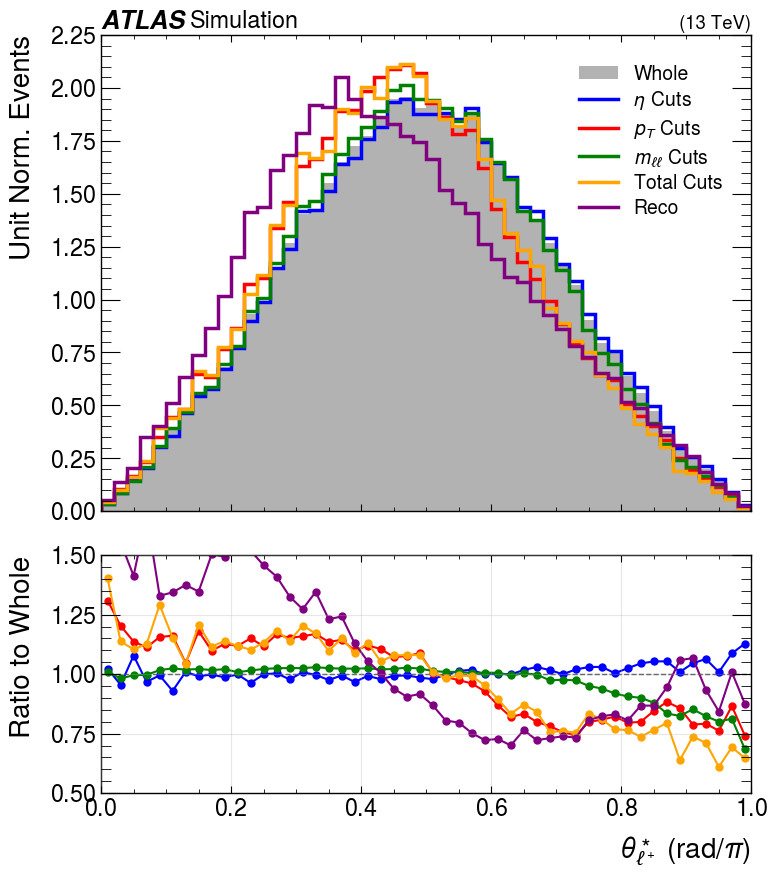

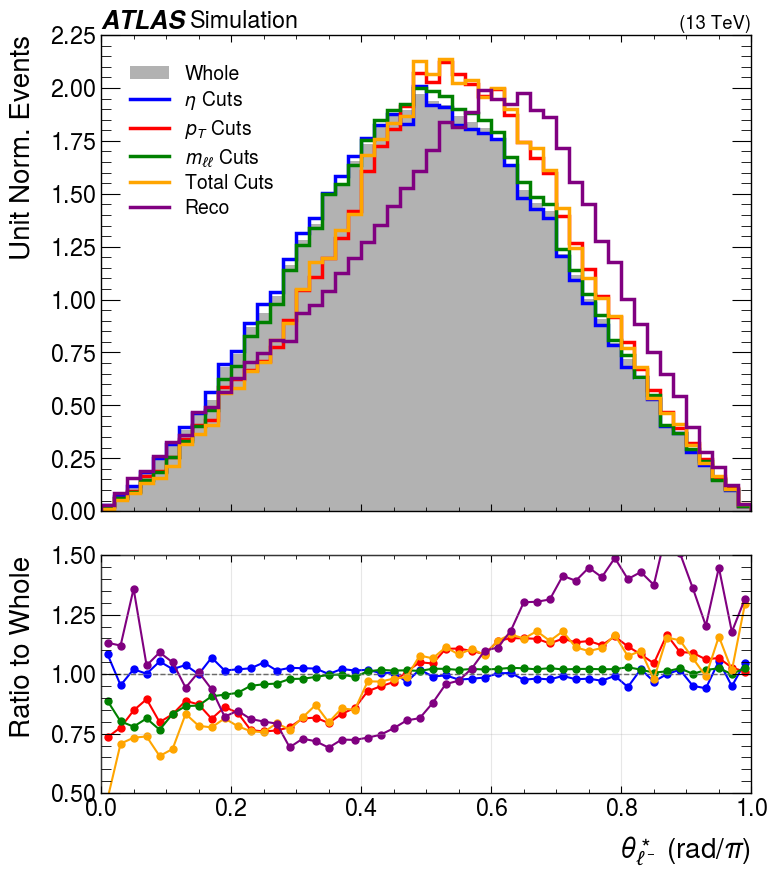

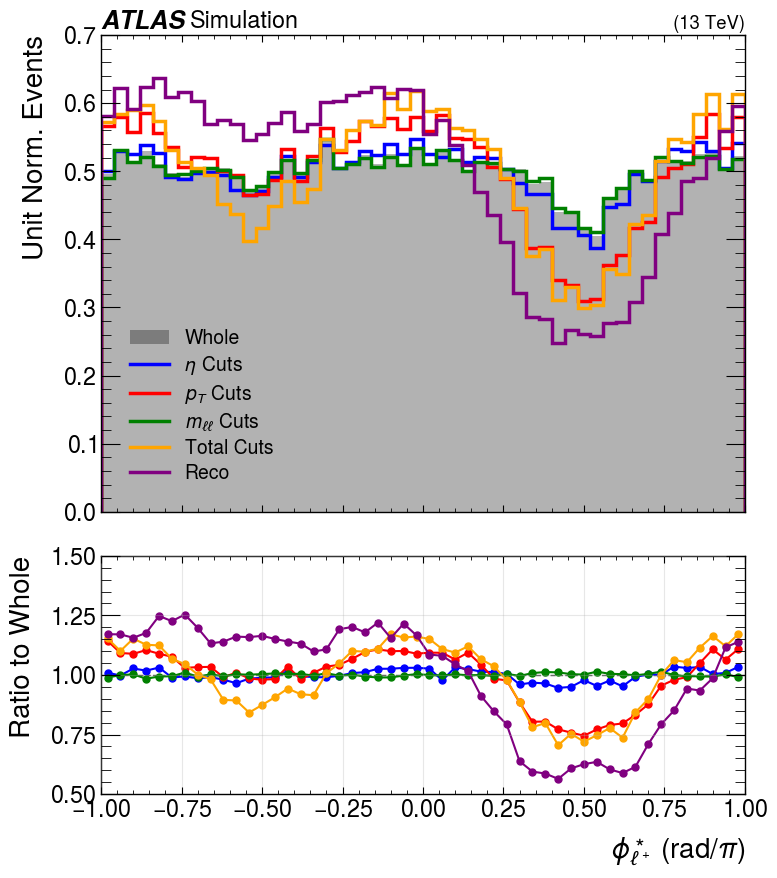

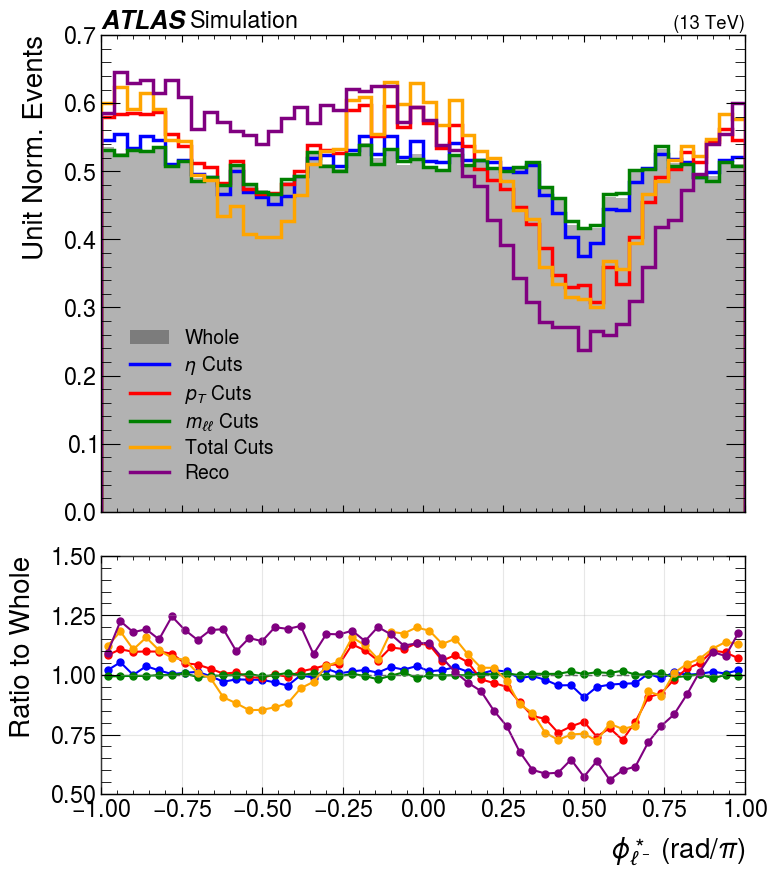

In [ ]:
import mplhep as hep

hep.style.use("ATLAS")

bins_edges = np.linspace(0, 1, 51)
phi_bins_edges = np.linspace(-1, 1, 51)

def plot_hist_with_ratio(data_dict, bins, xlabel, ylabel="Unit Norm. Events", title="", atlas_label="Internal"):
    """
    Plot histogram with ratio plots comparing to 'Whole' baseline.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary with keys as labels and values as data arrays
    bins : array-like
        Bin edges
    xlabel : str
        Label for x-axis
    ylabel : str
        Label for y-axis
    title : str
        Title for the plot
    atlas_label : str
        ATLAS label type: "Internal", "Prelimin etc.
    """
    fig, (ax, ax_ratio) = plt.subplots(2, 1, figsize=(8, 9), 
                                        gridspec_kw={"height_ratios": (2, 1)}, 
                                        sharex=True)
    
    # Extract baseline (Whole)
    whole_data = data_dict.pop("Whole")
    whole_counts, bin_edges = np.histogram(whole_data, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    # Plot baseline as bar
    hep.histplot(
        whole_counts, bin_edges, ax=ax, histtype="fill", alpha=0.3, color="black", label="Whole", linewidth=2
        )
    
    # Colors for other distributions
    colors = ["blue", "red", "green", "orange", "purple"]
    
    # Plot other distributions
    for idx, (label, data) in enumerate(data_dict.items()):
        counts, _ = np.histogram(data, bins=bins, density=True)
        
        # Plot on main axis
        hep.histplot(
            counts, bin_edges, ax=ax, histtype="step", linewidth=2.5, color=colors[idx % len(colors)], label=label
            )
        
        # Plot ratio
        ratio = counts / (whole_counts + 1e-10)  # Avoid division by zero
        ax_ratio.errorbar(
            bin_centers, ratio, fmt='o-', markersize=5, color=colors[idx % len(colors)], label=label, linewidth=1.5
            )
    
    # Add ATLAS label
    hep.atlas.label(label=atlas_label, ax=ax, loc=0, fontsize=14)
    
    # Formatting
    ax.legend(loc="best", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=20)
    # ax.set_title(title, fontsize=14, fontweight="bold")
    
    # Ratio axis formatting
    ax_ratio.axhline(y=1, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax_ratio.set_ylabel("Ratio to Whole", fontsize=20)
    ax_ratio.set_xlabel(xlabel, fontsize=20)
    ax_ratio.set_ylim([0.5, 1.5])
    ax_ratio.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot l0 theta
plot_hist_with_ratio(
    {
        "Whole": true_l0_theta_phi[0],
        r"$\eta$ Cuts": true_l0_theta_phi[0][eta_mask],
        r"$p_T$ Cuts": true_l0_theta_phi[0][pt_mask],
        r"$m_{\ell\ell}$ Cuts": true_l0_theta_phi[0][dilep_mass_mask],
        r"Total Cuts": true_l0_theta_phi[0][tot_cut],
        r"Reco": l0_theta_phi[0],
    },
    bins=bins_edges,
    xlabel=r"$\theta^\ast_{\ell^+}$ (rad/$\pi$)",
    title=r"Leading Lepton $\theta^\ast$",
    atlas_label=""
)

# Plot l1 theta
plot_hist_with_ratio(
    {
        "Whole": true_l1_theta_phi[0],
        r"$\eta$ Cuts": true_l1_theta_phi[0][eta_mask],
        r"$p_T$ Cuts": true_l1_theta_phi[0][pt_mask],
        r"$m_{\ell\ell}$ Cuts": true_l1_theta_phi[0][dilep_mass_mask],
        r"Total Cuts": true_l1_theta_phi[0][tot_cut],
        r"Reco": l1_theta_phi[0],
    },
    bins=bins_edges,
    xlabel=r"$\theta^\ast_{\ell^-}$ (rad/$\pi$)",
    title=r"Subleading Lepton $\theta^\ast$",
    atlas_label=""
)

# Plot l0 phi
plot_hist_with_ratio(
    {
        "Whole": true_l0_theta_phi[1],
        r"$\eta$ Cuts": true_l0_theta_phi[1][eta_mask],
        r"$p_T$ Cuts": true_l0_theta_phi[1][pt_mask],
        r"$m_{\ell\ell}$ Cuts": true_l0_theta_phi[1][dilep_mass_mask],
        r"Total Cuts": true_l0_theta_phi[1][tot_cut],
        r"Reco": l0_theta_phi[1],
    },
    bins=phi_bins_edges,
    xlabel=r"$\phi^\ast_{\ell^+}$ (rad/$\pi$)",
    title=r"Leading Lepton $\phi^\ast$",
    atlas_label=""
)

# Plot l1 phi
plot_hist_with_ratio(
    {
        "Whole": true_l1_theta_phi[1],
        r"$\eta$ Cuts": true_l1_theta_phi[1][eta_mask],
        r"$p_T$ Cuts": true_l1_theta_phi[1][pt_mask],
        r"$m_{\ell\ell}$ Cuts": true_l1_theta_phi[1][dilep_mass_mask],
        r"Total Cuts": true_l1_theta_phi[1][tot_cut],
        r"Reco": l1_theta_phi[1],
    },
    bins=phi_bins_edges,
    xlabel=r"$\phi^\ast_{\ell^-}$ (rad/$\pi$)",
    title=r"Subleading Lepton $\phi^\ast$",
    atlas_label=""
)

In [ ]:
# distribution inspection 


In [ ]:
# Pzv1 and Ev1 are unknowns

mh = 125.0

def A(Ew0, El1):    
    return Ew0 + El1

def B(
        Pxw0, Pxw1, 
        Pyw0, Pyw1,
        Pzl1, Pzw0
    ):
    Pxh = Pxw0 + Pxw1
    Pyh = Pyw0 + Pyw1
    
    return Pxh + Pyh + Pzw0 + Pzl1

def Ptv1(Pxw1, Pxl1, Pyw1, Pyl1): # can be regressed from NN
    Pxv1 = Pxw1 - Pxl1
    Pyv1 = Pyw1 - Pyl1
    return np.sqrt(Pxv1**2 + Pyv1**2)

def C(A, B, Ptv1):
    return 0.25 * (mh**2 + (B**2 - A**2) - Ptv1**2)**2 -A**2 * Ptv1**2



def trunk(A, B, C, Ptv1):
    term = (A**2 * B**2 * (C + A**2 * Ptv1**2) * (C + B**2 * Ptv1**2))
    return B**2 * C + 2 * np.sqrt(term) + A**2 * (C + 2 * B**2 * Ptv1**2)

def Pzv1_sol1(A, B, C, Ptv1):
    term = trunk(A, B, C, Ptv1)
    return - np.sqrt(C**2 / term)

def Pzv1_sol2(A, B, C, Ptv1):
    term = trunk(A, B, C, Ptv1)
    return np.sqrt(C**2 / term)

def Pzv1_sol3(A, B, C, Ptv1):
    term1 = trunk(A, B, C, Ptv1)
    term2 = (A**2 - B**2)**2
    return -np.sqrt(term1 / term2)

def Pzv1_sol4(A, B, C, Ptv1):
    term1 = trunk(A, B, C, Ptv1)
    term2 = (A**2 - B**2)**2
    return np.sqrt(term1 / term2)

In [ ]:
A_values = A(truth_w_pos_e, truth_lep_neg_energy)
B_values = B(
	truth_w_pos_px, truth_w_neg_px,
	truth_w_pos_py, truth_w_neg_py,
	truth_lep_neg_pz, truth_w_pos_pz
)
Ptv1_values = Ptv1(truth_w_neg_px, truth_lep_neg_px, truth_w_neg_py, truth_lep_neg_py)
C_values = C(A_values, B_values, Ptv1_values)


# pick up solution 
Pzv1_sol1_values = Pzv1_sol1(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol2_values = Pzv1_sol2(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol3_values = Pzv1_sol3(A_values, B_values, C_values, Ptv1_values)
Pzv1_sol4_values = Pzv1_sol4(A_values, B_values, C_values, Ptv1_values)

/tmp/ipykernel_849150/1582335212.py:30: RuntimeWarning: invalid value encountered in sqrt
  return B**2 * C + 2 * np.sqrt(term) + A**2 * (C + 2 * B**2 * Ptv1**2)
/tmp/ipykernel_849150/1582335212.py:34: RuntimeWarning: invalid value encountered in sqrt
  return - np.sqrt(C**2 / term)
/tmp/ipykernel_849150/1582335212.py:38: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(C**2 / term)
/tmp/ipykernel_849150/1582335212.py:43: RuntimeWarning: invalid value encountered in sqrt
  return -np.sqrt(term1 / term2)
/tmp/ipykernel_849150/1582335212.py:48: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(term1 / term2)


In [ ]:
solutions = np.stack(
    [Pzv1_sol1_values, Pzv1_sol2_values, Pzv1_sol3_values, Pzv1_sol4_values],
    axis=1,
)

rng = np.random.default_rng(42)
selected_pzv1 = np.zeros(Pzv1_sol1_values.shape[0]) # default with 0
zeros_counts = 0
for i, row in enumerate(solutions):
    valid = row[np.isfinite(row)]
    if len(valid) > 0:
        selected_pzv1[i] = rng.choice(valid)
        # selected_pzv1[i] = valid.mean() # should always 0
    if len(valid) == 0:
        # print(f"No valid solution for event {i}")
        # print("Solutions:", row)
        zeros_counts += 1

print(f"Number of events with no valid Pzv1 solution: {100*zeros_counts/solutions.shape[0]:.2f}%")
print("Selected Pzv1 shape:", selected_pzv1.shape)

Number of events with no valid Pzv1 solution: 25.57%
Selected Pzv1 shape: (75569,)


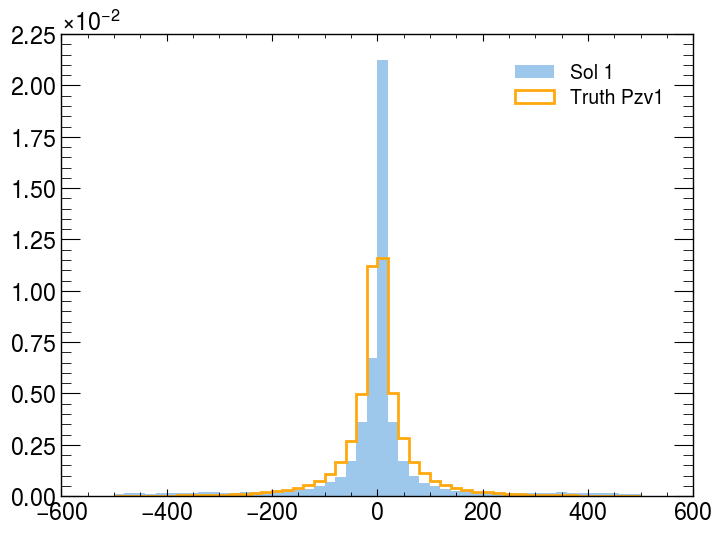

In [ ]:
plt.hist(selected_pzv1, bins=np.linspace(-500, 500, 51), alpha=0.5, label="Sol 1", density=True)
plt.hist(antinu_pz, bins=np.linspace(-500, 500, 51), histtype="step", linewidth=2, label="Truth Pzv1", density=True)
plt.legend()
plt.show()


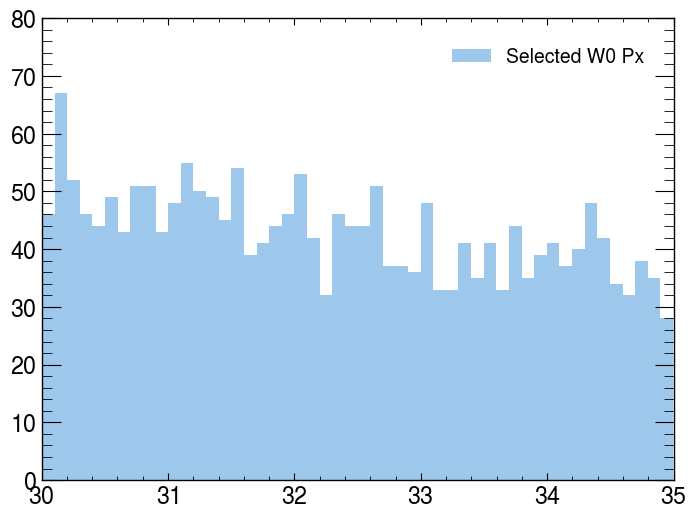

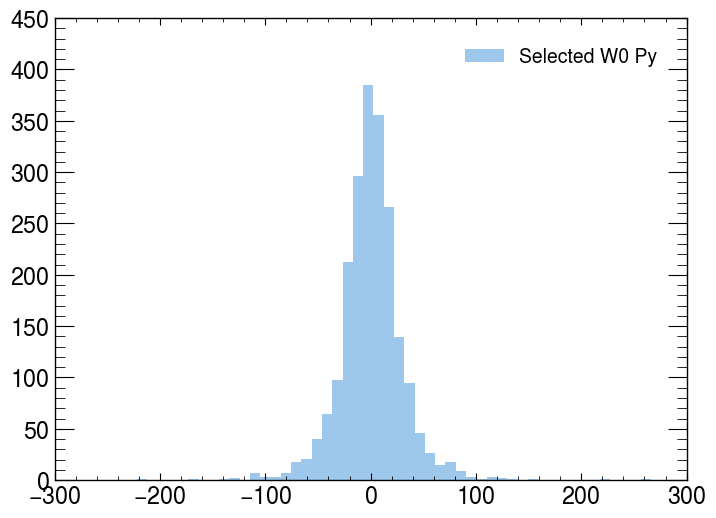

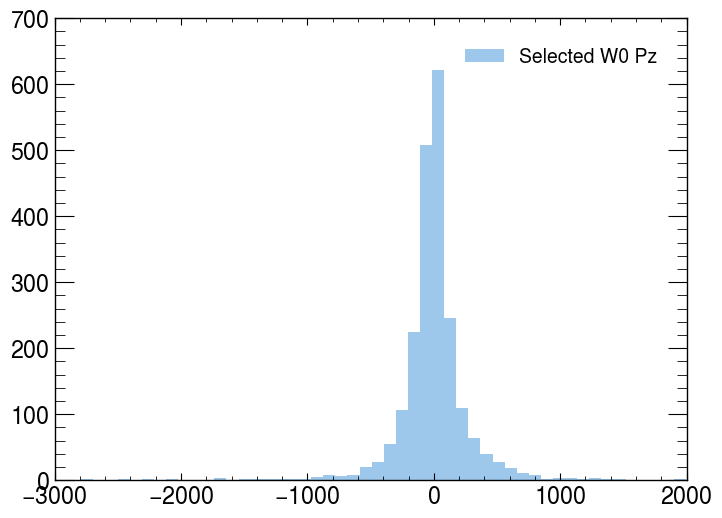

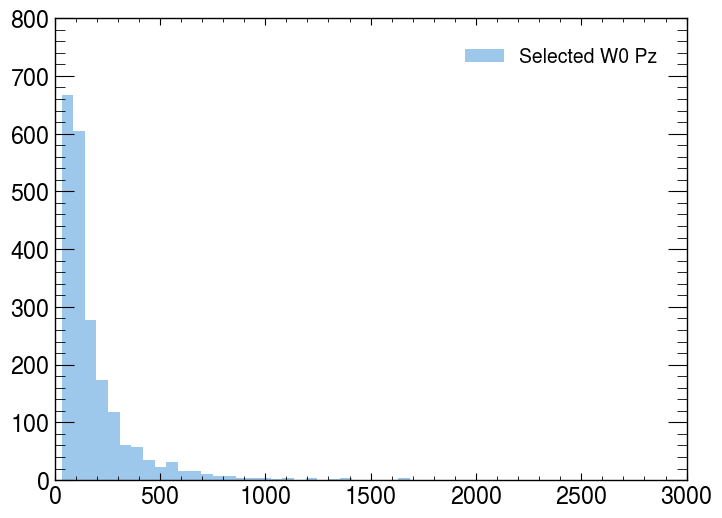

In [ ]:
# check conditional probabilities
sel_w0_px_mask = (30 < truth_w_pos_px) & (truth_w_pos_px < 35)
sel_w0_px = truth_w_pos_px[sel_w0_px_mask]
sel_w0_py = truth_w_pos_py[sel_w0_px_mask]
sel_w0_pz = truth_w_pos_pz[sel_w0_px_mask]
sel_w0_e = truth_w_pos_e[sel_w0_px_mask]

plt.hist(sel_w0_px, bins=50, alpha=0.5, label="Selected W0 Px", density=False)
plt.legend()
plt.show()
plt.hist(sel_w0_py, bins=50, alpha=0.5, label="Selected W0 Py", density=False)
plt.legend()
plt.show()
plt.hist(sel_w0_pz, bins=50, alpha=0.5, label="Selected W0 Pz", density=False)
plt.legend()
plt.show()
plt.hist(sel_w0_e, bins=50, alpha=0.5, label="Selected W0 Pz", density=False)
plt.legend()
plt.show()

Pearson correlation (all):
[[ 1.    -0.001 -0.001 -0.004  0.253 -0.003 -0.    -0.001]
 [-0.001  1.     0.01  -0.003  0.001  0.248  0.002  0.006]
 [-0.001  0.01   1.    -0.012  0.    -0.001  0.702 -0.001]
 [-0.004 -0.003 -0.012  1.     0.002 -0.    -0.002  0.492]
 [ 0.253  0.001  0.     0.002  1.     0.    -0.003 -0.002]
 [-0.003  0.248 -0.001 -0.     0.     1.     0.005  0.009]
 [-0.     0.002  0.702 -0.002 -0.003  0.005  1.    -0.005]
 [-0.001  0.006 -0.001  0.492 -0.002  0.009 -0.005  1.   ]]

Pearson correlation (conditioned: 30 < px < 35):
[[ 1.    -0.001 -0.001 -0.004  0.253 -0.003 -0.    -0.001]
 [-0.001  1.     0.01  -0.003  0.001  0.248  0.002  0.006]
 [-0.001  0.01   1.    -0.012  0.    -0.001  0.702 -0.001]
 [-0.004 -0.003 -0.012  1.     0.002 -0.    -0.002  0.492]
 [ 0.253  0.001  0.     0.002  1.     0.    -0.003 -0.002]
 [-0.003  0.248 -0.001 -0.     0.     1.     0.005  0.009]
 [-0.     0.002  0.702 -0.002 -0.003  0.005  1.    -0.005]
 [-0.001  0.006 -0.001  0.492 -0.002 

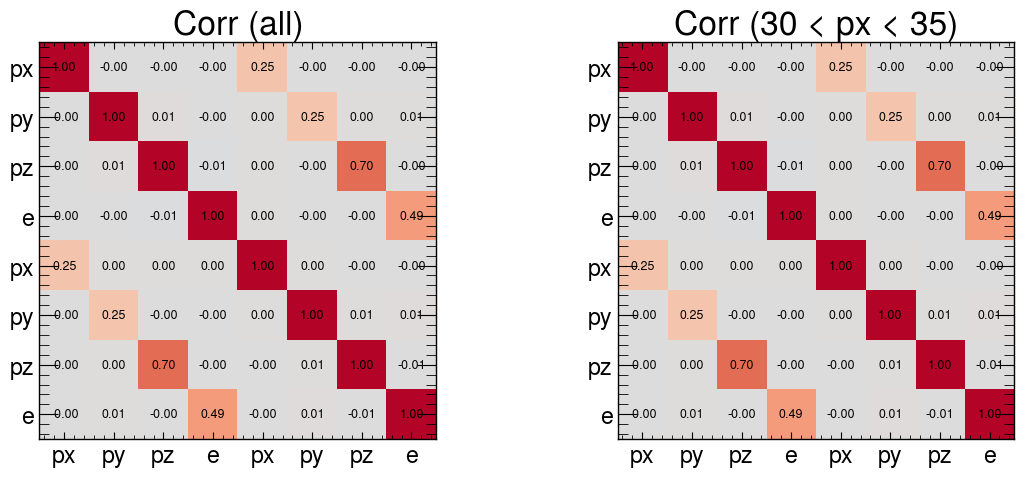


Delta correlation (conditioned - all):
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
# Correlation check for [px, py, pz, e]: full sample vs conditioned sample
var_names = ["px", "py", "pz", "e"]*2

all_stack = np.column_stack([truth_w_pos_px, truth_w_pos_py, truth_w_pos_pz, truth_w_pos_e,\
                            truth_w_neg_px, truth_w_neg_py, truth_w_neg_pz, truth_w_neg_e])
cond_stack = np.column_stack([
    truth_w_pos_px,
    truth_w_pos_py,
    truth_w_pos_pz,
    truth_w_pos_e,
    truth_w_neg_px,
    truth_w_neg_py,
    truth_w_neg_pz,
    truth_w_neg_e,
])

corr_all = np.corrcoef(all_stack, rowvar=False)
corr_cond = np.corrcoef(cond_stack, rowvar=False)

print("Pearson correlation (all):")
print(np.array2string(corr_all, precision=3, suppress_small=True))
print("\nPearson correlation (conditioned: 30 < px < 35):")
print(np.array2string(corr_cond, precision=3, suppress_small=True))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vmin, vmax = -1, 1

im0 = axes[0].imshow(corr_all, vmin=vmin, vmax=vmax, cmap="coolwarm")
axes[0].set_title("Corr (all)")
axes[0].set_xticks(range(len(var_names)))
axes[0].set_yticks(range(len(var_names)))
axes[0].set_xticklabels(var_names)
axes[0].set_yticklabels(var_names)

im1 = axes[1].imshow(corr_cond, vmin=vmin, vmax=vmax, cmap="coolwarm")
axes[1].set_title("Corr (30 < px < 35)")
axes[1].set_xticks(range(len(var_names)))
axes[1].set_yticks(range(len(var_names)))
axes[1].set_xticklabels(var_names)
axes[1].set_yticklabels(var_names)

for ax, mat in zip(axes, [corr_all, corr_cond]):
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

# fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85, label="Pearson r")
plt.tight_layout()
plt.show()

print("\nDelta correlation (conditioned - all):")
print(np.array2string(corr_cond - corr_all, precision=3, suppress_small=True))

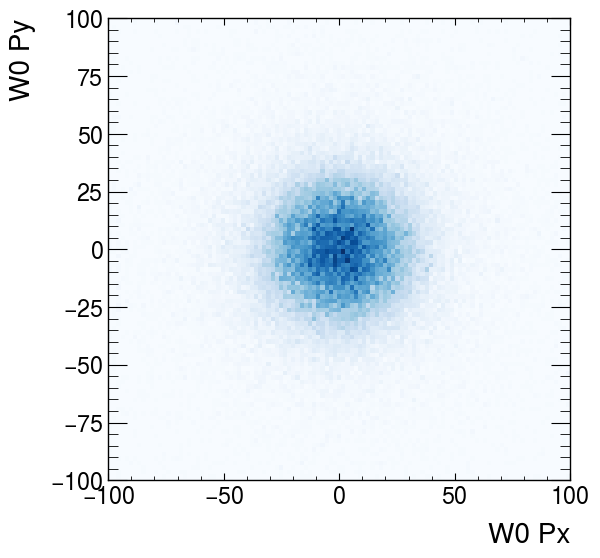

In [ ]:
plt.hist2d(truth_w_pos_px, truth_w_pos_py, bins=500, cmap="Blues")
plt.xlabel("W0 Px")
plt.ylabel("W0 Py")
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

In [ ]:
def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2
true_w0_mass_2 = truth_w_pos["energy"]**2 - truth_w_pos["px"]**2 - truth_w_pos["py"]**2 - truth_w_pos["pz"]**2
true_w1_mass_2 = truth_w_neg["energy"]**2 - truth_w_neg["px"]**2 - truth_w_neg["py"]**2 - truth_w_neg["pz"]**2
true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_l0_p4 = np.stack([truth_pos_lep["px"], truth_pos_lep["py"], truth_pos_lep["pz"], truth_pos_lep["energy"]], axis=1)
true_l1_p4 = np.stack([truth_neg_lep["px"], truth_neg_lep["py"], truth_neg_lep["pz"], truth_neg_lep["energy"]], axis=1)
true_w0_p4 = np.stack([truth_w_pos["px"], truth_w_pos["py"], truth_w_pos["pz"], truth_w_pos["energy"]], axis=1)
true_w1_p4 = np.stack([truth_w_neg["px"], truth_w_neg["py"], truth_w_neg["pz"], truth_w_neg["energy"]], axis=1)
true_lep_on_p4 = np.where(np.expand_dims(true_0_on_mask, axis=-1), true_l0_p4, true_l1_p4)
true_lep_off_p4 = np.where(np.expand_dims(true_0_on_mask, axis=-1), true_l1_p4, true_l0_p4)
true_w0_on_p4 = np.where(np.expand_dims(true_0_on_mask, axis=-1), true_w0_p4, true_w1_p4)
true_w1_on_p4 = np.where(np.expand_dims(true_0_on_mask, axis=-1), true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w0_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w1_on_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
# pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

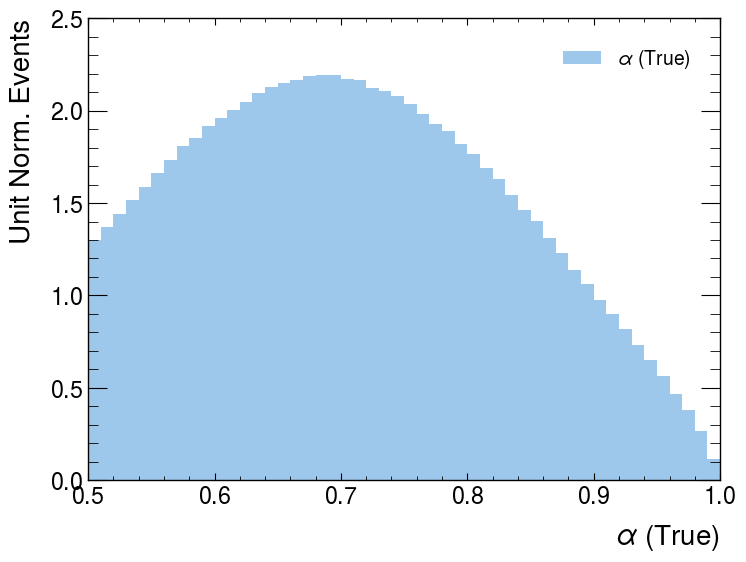

In [ ]:
bins_edges = np.linspace(0, 1, 101)
plt.hist(true_alpha, bins=bins_edges, alpha=0.5, label=r"$\alpha$ (True)", density=True)
# plt.hist(pred_alpha, bins=bins_edges, histtype="step", linewidth=2, label=r"$\alpha$ (Pred)", density=True)
plt.legend()
plt.xlabel(r"$\alpha$ (True)", fontsize=20)
plt.ylabel("Unit Norm. Events", fontsize=20)
plt.xlim([0.5,1])
plt.show()

In [ ]:
from scipy.stats import multivariate_normal, norm

# p_mask = (np.abs(truth_w_pos["px"]) < 200) & (np.abs(truth_w_pos["py"]) < 200) & (np.abs(truth_w_pos["pz"]) < 1000)
p_mask = (np.abs(truth_w_pos["px"]) < 500) & (np.abs(truth_w_pos["py"]) < 500)
print(f"Applying p_mask cuts out {len(p_mask) - np.sum(p_mask)} events, surviving rate: {100 * np.sum(p_mask) / len(p_mask):.2f}%")

mom = np.stack([truth_w_pos["px"], truth_w_pos["py"], truth_w_pos["pz"]], axis=-1)
# mom = np.stack([truth_w_pos["px"][p_mask], truth_w_pos["py"][p_mask]], axis=-1)
mean = np.mean(mom, axis=0)
cov = np.cov(mom, rowvar=False)
rv = multivariate_normal(mean=mean, cov=cov, seed=114)
bins_edge = np.linspace(-500, 500, 101)

Applying p_mask cuts out 57 events, surviving rate: 100.00%


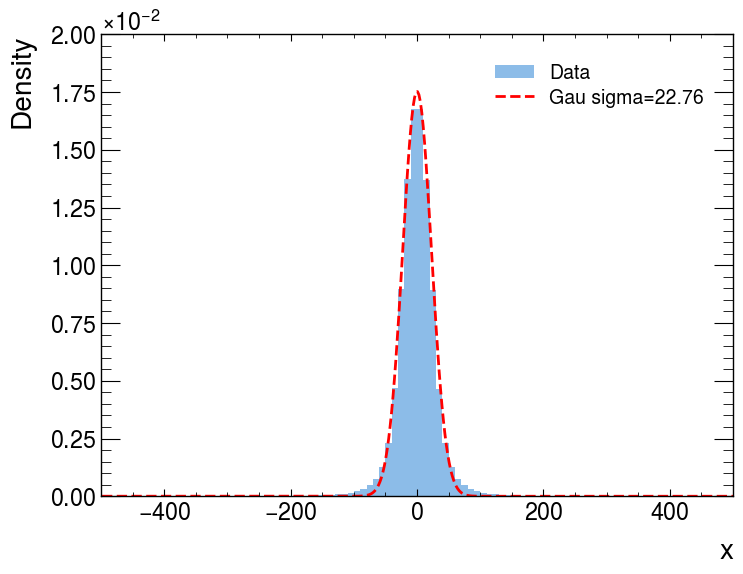

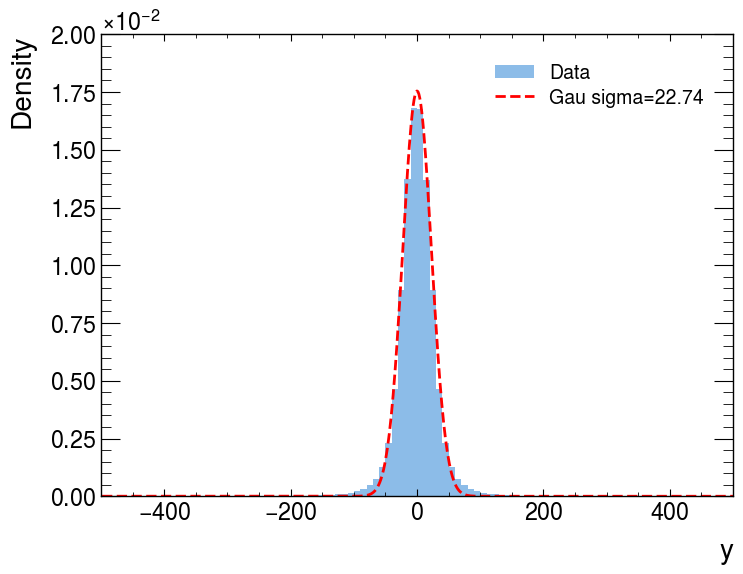

array([22.73628222])

In [ ]:
from scipy.optimize import curve_fit

def _pdf(x, sigma1):
    return norm.pdf(x, loc=0.0, scale=sigma1)

def plot_two_gaussian_fit(data, bins, label, p0=(20.0), bounds=None):
    counts, edges = np.histogram(data, bins=int(1e5), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    if bounds is None:
        bounds = ([1e-3], [100.0])
    params, _ = curve_fit(_pdf, centers, counts, p0=p0, bounds=bounds)
    sigma1 = params[0]

    xs = np.linspace(edges[0], edges[-1], 1000)
    fit_curves = norm.pdf(xs, loc=0.0, scale=sigma1)

    plt.hist(data, bins=bins, density=True, alpha=0.6, label="Data")
    plt.plot(xs, fit_curves, "r--", label=f"Gau sigma={sigma1:.2f}")
    plt.xlabel(label)
    plt.ylabel("Density")
    # plt.semilogx()
    # plt.semilogy()
    plt.legend()
    plt.xlim(bins[0], bins[-1])
    plt.show()
    return params

param = plot_two_gaussian_fit(mom[:, 0], bins=bins_edge, label="x")
plot_two_gaussian_fit(mom[:, 1], bins=bins_edge, label="y")

opt_func: sigma1=22.763


/tmp/ipykernel_849150/191527636.py:8: RuntimeWarning: divide by zero encountered in divide
  plt.hist(truth_w_pos["px"], bins=bins_edge, weights=np.clip(1 / (opt_func(truth_w_pos["px"])), max=1e20), density=True, alpha=0.5, label="Reweighted (opt)")


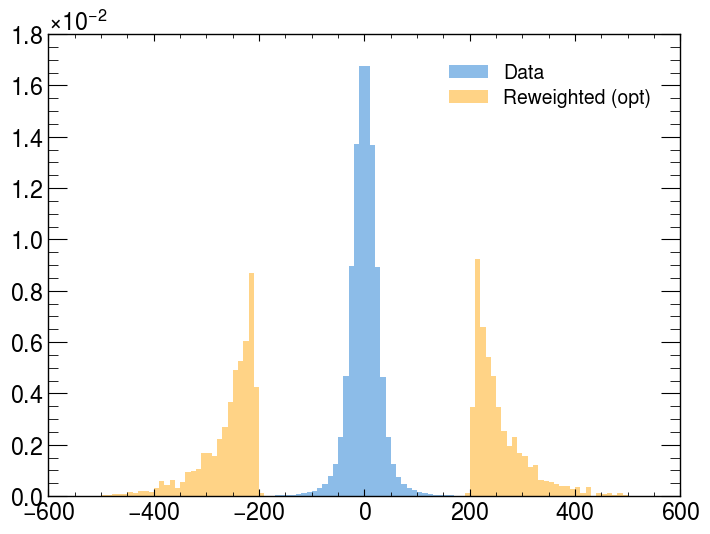

In [ ]:
def opt_func(data, params=param):
	sigma1 = params[0]
	pdf_vals = norm.pdf(data, loc=0.0, scale=sigma1)
	print(f"opt_func: sigma1={sigma1:.3f}")
	return pdf_vals

plt.hist(truth_w_pos["px"], bins=bins_edge, density=True, alpha=0.6, label="Data")
plt.hist(truth_w_pos["px"], bins=bins_edge, weights=np.clip(1 / (opt_func(truth_w_pos["px"])), max=1e20), density=True, alpha=0.5, label="Reweighted (opt)")
# plt.semilogy()
plt.legend()
plt.show()

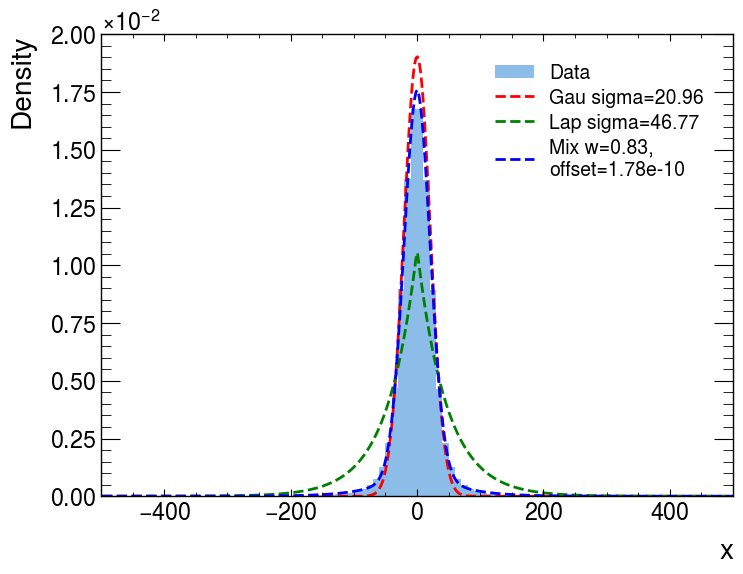

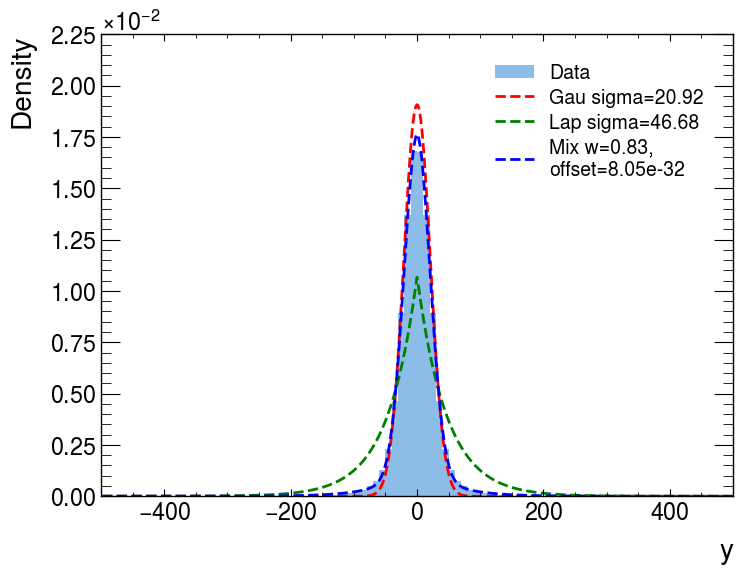

array([2.09209212e+01, 4.66830084e+01, 1.58347220e+00, 8.04608476e-32])

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import laplace

def _mix_pdf(x, sigma1, sigma2, w_logit, offset):
    w = 1.0 / (1.0 + np.exp(-w_logit)) # sigmoid to ensure w in (0, 1)
    return w * norm.pdf(x, loc=0.0, scale=sigma1) + (1.0 - w) * laplace.pdf(x, loc=0.0, scale=sigma2) + offset

def plot_two_gaussian_fit(data, bins, label, p0=(20.0, 60.0, 0.0, 0.0), bounds=None):
    counts, edges = np.histogram(data, bins=int(1e5), density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    if bounds is None:
        bounds = ([1e-3, 1e-3, 0.0, 0.0], [100.0, 100.0, 10.0, 10.0])
    params, _ = curve_fit(_mix_pdf, centers, counts, p0=p0, bounds=bounds)
    sigma1, sigma2, w_logit, offset = params
    w = 1.0 / (1.0 + np.exp(-w_logit))

    xs = np.linspace(edges[0], edges[-1], 1000)
    pdf1 = norm.pdf(xs, loc=0.0, scale=sigma1)
    pdf2 = laplace.pdf(xs, loc=0.0, scale=sigma2)
    pdf_mix = w * pdf1 + (1.0 - w) * pdf2

    plt.hist(data, bins=bins, density=True, alpha=0.6, label="Data")
    plt.plot(xs, pdf1, "r--", label=f"Gau sigma={sigma1:.2f}")
    plt.plot(xs, pdf2, "g--", label=f"Lap sigma={sigma2:.2f}")
    plt.plot(xs, pdf_mix + offset, "b--", label=f"Mix w={w:.2f},\noffset={offset:.2e}")
    plt.xlabel(label)
    plt.ylabel("Density")
    # plt.semilogx()
    # plt.semilogy()
    plt.legend()
    plt.xlim(bins[0], bins[-1])
    plt.show()
    return params

param = plot_two_gaussian_fit(mom[:, 0], bins=bins_edge, label="x")
plot_two_gaussian_fit(mom[:, 1], bins=bins_edge, label="y")

opt_func: sigma1=20.961, sigma2=46.772, w=0.831, offset=1.779e-10


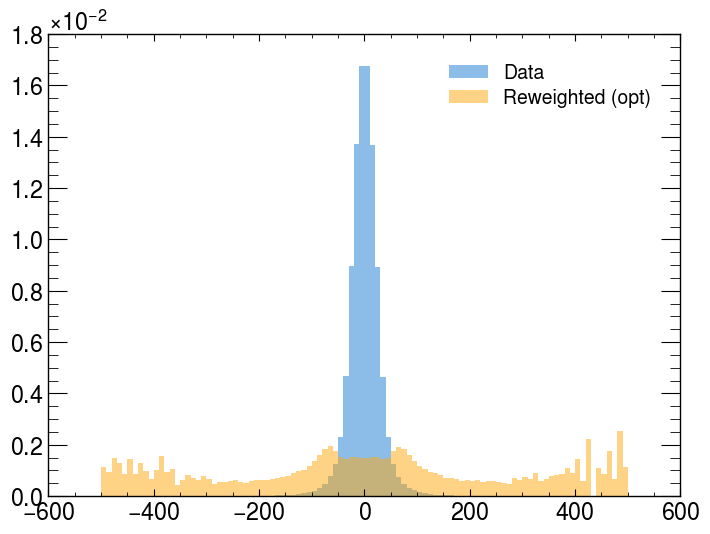

In [ ]:
def opt_func(data, params=param):
	sigma1, sigma2, w_logit, offset = params
	w = 1.0 / (1.0 + np.exp(-w_logit))
	pdf_vals = w * norm.pdf(data, loc=0.0, scale=sigma1) + (1.0 - w) * laplace.pdf(data, loc=0.0, scale=sigma2) + offset
	print(f"opt_func: sigma1={sigma1:.3f}, sigma2={sigma2:.3f}, w={w:.3f}, offset={offset:.3e}")
	return pdf_vals

plt.hist(truth_w_pos["px"], bins=bins_edge, density=True, alpha=0.6, label="Data")
plt.hist(truth_w_pos["px"], bins=bins_edge, weights=np.clip(1 / (opt_func(truth_w_pos["px"])), max=1e20), density=True, alpha=0.5, label="Reweighted (opt)")
# plt.semilogy()
plt.legend()
plt.show()